<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/29_march_Regression_4_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Science Master

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import (
    Lasso, LassoCV, Ridge, LinearRegression, ElasticNet
)
from sklearn.preprocessing import (
    StandardScaler, PolynomialFeatures, OneHotEncoder
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F7F9FC',
    'axes.grid'        : True,
    'grid.alpha'       : 0.38,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
})

# Colour palette
C1='#E94560'   # vivid red
C2='#0f3460'   # deep navy
C3='#16213e'   # dark slate
C4='#2EC4B6'   # teal
C5='#FF9F1C'   # amber
C6='#6A0572'   # purple

print('✅  Libraries loaded successfully.')
print(f'    NumPy {np.__version__} | Pandas {pd.__version__}')


✅  Libraries loaded successfully.
    NumPy 2.0.2 | Pandas 2.2.2


---
## Q1 — What is Lasso Regression, and how does it differ from other regression techniques?


### 📖 Theory

**Lasso** (*Least Absolute Shrinkage and Selection Operator*) is a regularised linear model
that adds an **L1 penalty** — the sum of *absolute* coefficient values — to the ordinary least-squares loss.

$$\text{Lasso Objective} = \underbrace{\sum_{i=1}^{n}(y_i - \hat y_i)^2}_{\text{RSS}} \ + \ \lambda\underbrace{\sum_{j=1}^{p}|\beta_j|}_{\text{L1 penalty}}$$

#### How Lasso differs from other techniques

| Technique | Penalty | Coefficients reach 0? | Feature selection | Best when |
|-----------|---------|----------------------|-------------------|----------|
| **OLS** | None | — | ❌ | Low collinearity, n ≫ p |
| **Ridge** | $\lambda\sum\beta_j^2$ (L2) | ❌ Never | ❌ | All features useful |
| **Lasso** | $\lambda\sum|\beta_j|$ (L1) | ✅ Yes | ✅ Automatic | Many irrelevant features |
| **Elastic Net** | L1 + L2 | ✅ Yes | ✅ | Correlated + sparse |

> 🔑 **Key insight:** The L1 diamond-shaped constraint region has *corners on the axes*,
> so the optimal solution often hits a corner where some $\beta_j = 0$ — producing a **sparse model**.


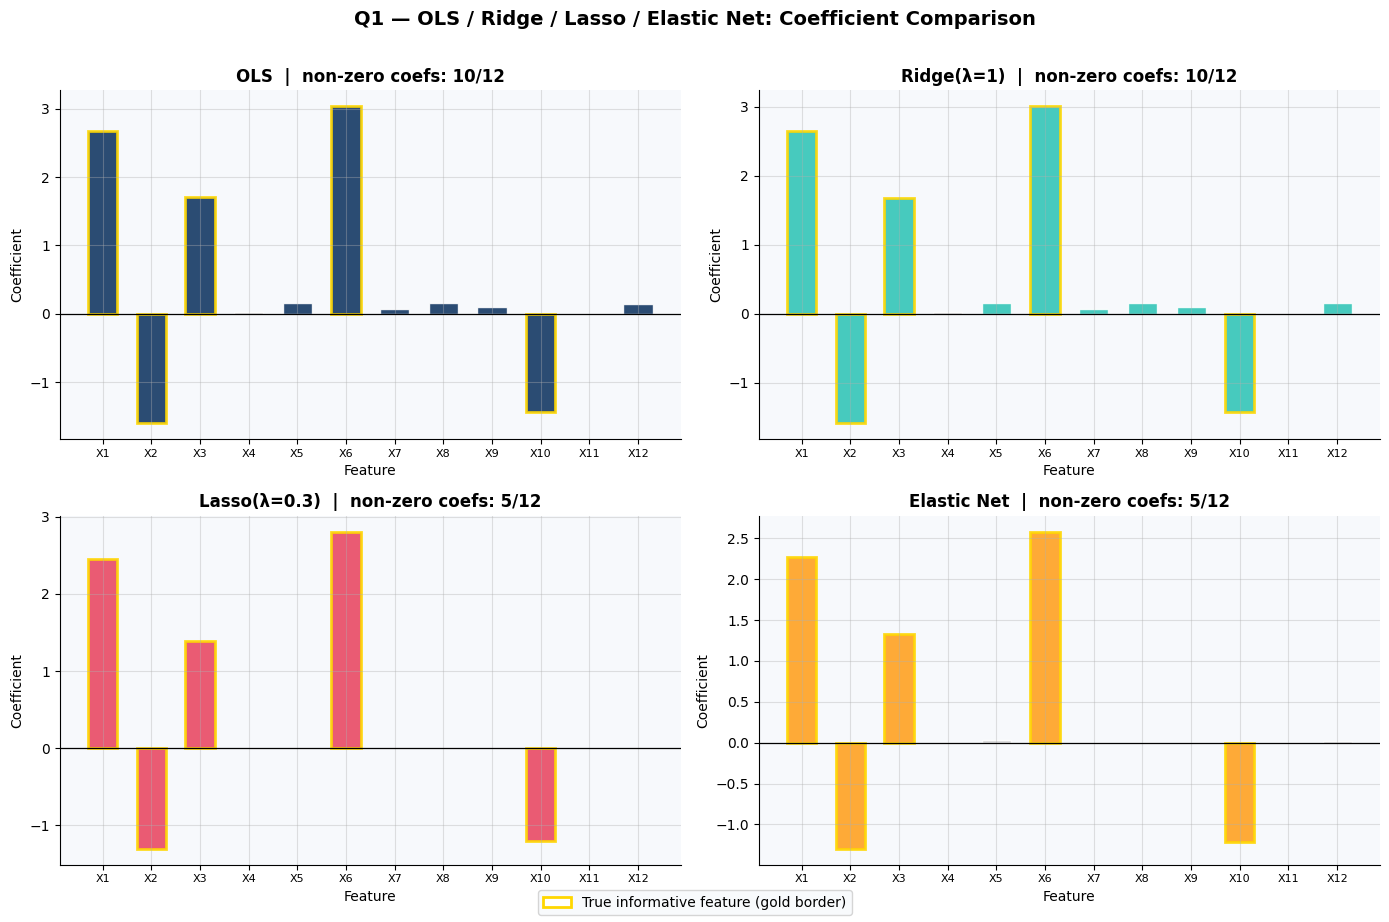

True non-zero features: X1, X2, X3, X6, X10
Lasso correctly zeroes out noise features → sparse model!


In [2]:
# ── Q1: visualise OLS / Ridge / Lasso coefficient differences ───────────────
np.random.seed(42)
n, p = 100, 12

# Only 4 of 12 features are truly informative
true_coef = np.array([3.5, -2.0, 1.8, 0.0, 0.0, 2.5,
                       0.0, 0.0, 0.0, -1.2, 0.0, 0.0])
X, y, _ = make_regression(n_samples=n, n_features=p,
                           noise=12, coef=True, random_state=42)
# Manually set y to match our true_coef
np.random.seed(42)
X = np.random.randn(n, p)
y = X @ true_coef + np.random.randn(n) * 2.5

sc = StandardScaler()
Xs = sc.fit_transform(X)

models = {
    'OLS'        : LinearRegression(),
    'Ridge(λ=1)' : Ridge(alpha=1.0),
    'Lasso(λ=0.3)': Lasso(alpha=0.3, max_iter=10000),
    'Elastic Net' : ElasticNet(alpha=0.3, l1_ratio=0.5, max_iter=10000),
}

palette = [C2, C4, C1, C5]
feat_labels = [f'X{i+1}' for i in range(p)]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (name, mdl), col in zip(axes, models.items(), palette):
    mdl.fit(Xs, y)
    coefs = mdl.coef_
    colors = [col if abs(c) > 0.05 else '#D3D3D3' for c in coefs]
    bars = ax.bar(feat_labels, coefs, color=colors, alpha=0.88, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', lw=0.9)
    # Mark true non-zero features
    for i, tc in enumerate(true_coef):
        if abs(tc) > 0:
            ax.get_xticklabels()  # placeholder
            bars[i].set_edgecolor('gold')
            bars[i].set_linewidth(2)
    nz = np.sum(np.abs(coefs) > 0.05)
    ax.set_title(f'{name}  |  non-zero coefs: {nz}/{p}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Coefficient')
    ax.set_xlabel('Feature')
    ax.tick_params(axis='x', labelsize=8)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(edgecolor='gold', facecolor='white', lw=2,
                           label='True informative feature (gold border)')],
           loc='lower center', fontsize=10, ncol=1)
plt.suptitle('Q1 — OLS / Ridge / Lasso / Elastic Net: Coefficient Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('True non-zero features: X1, X2, X3, X6, X10')
print('Lasso correctly zeroes out noise features → sparse model!')


---
## Q2 — What is the main advantage of using Lasso Regression in feature selection?


### 📖 Theory

The primary advantage of Lasso is **automatic, built-in feature selection via sparse solutions**.

#### Why Lasso produces exact zeros (geometry)

The L1 constraint region is a **diamond** with corners on the coordinate axes.  
When the RSS ellipse first touches this diamond, it almost always hits a **corner** →  
one or more $\beta_j = 0$ exactly.

#### Advantages over manual selection

| Benefit | Description |
|---------|-------------|
| **Automatic** | No need for stepwise search or domain rules |
| **Interpretable** | Produces a minimal, readable model |
| **Reduced overfitting** | Fewer features → lower model variance |
| **Works in high dimensions** | Handles p ≫ n (more features than samples) |
| **Continuous shrinkage** | Soft thresholding, not hard cutoff |

> **Soft-thresholding rule (coordinate descent):**
> $$\hat\beta_j = \text{sign}(\tilde\beta_j)\cdot\max(|\tilde\beta_j| - \lambda,\ 0)$$
> When $|\tilde\beta_j| \le \lambda$ the coefficient is *exactly* zeroed.


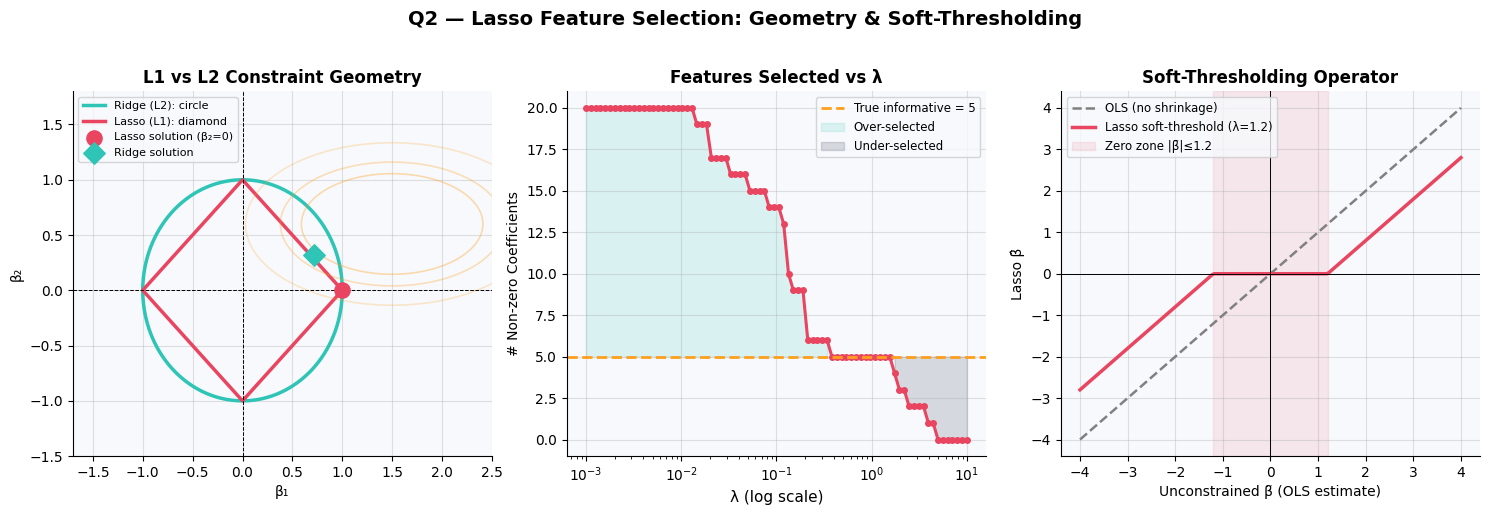

In [3]:
# ── Q2: L1 vs L2 constraint geometry + automatic feature selection ───────────
np.random.seed(0)

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── Panel 1: constraint region geometry ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
theta = np.linspace(0, 2*np.pi, 400)

# L2 (circle)
ax1.plot(np.cos(theta), np.sin(theta), color=C4, lw=2.5, label='Ridge (L2): circle')
# L1 (diamond)
diamond_x = [1, 0, -1, 0, 1]
diamond_y = [0, 1,  0,-1, 0]
ax1.plot(diamond_x, diamond_y, color=C1, lw=2.5, label='Lasso (L1): diamond')

# RSS ellipse
for scale, alpha in [(0.65, 0.25), (0.80, 0.20), (1.05, 0.12)]:
    ex = scale*1.4*np.cos(theta) + 1.5
    ey = scale*0.7*np.sin(theta) + 0.6
    ax1.plot(ex, ey, color=C5, lw=1.2, alpha=alpha+0.1)

# Intersection point (Lasso hits corner → β2=0)
ax1.scatter([1], [0], s=120, color=C1, zorder=6, label='Lasso solution (β₂=0)')
ax1.scatter([0.72], [0.32], s=120, color=C4, marker='D', zorder=6, label='Ridge solution')
ax1.axhline(0, color='black', lw=0.7, ls='--')
ax1.axvline(0, color='black', lw=0.7, ls='--')
ax1.set_xlim(-1.7, 2.5); ax1.set_ylim(-1.5, 1.8)
ax1.set_xlabel('β₁'); ax1.set_ylabel('β₂')
ax1.set_title('L1 vs L2 Constraint Geometry', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)

# ── Panel 2: feature selection as λ increases ─────────────────────────────────
ax2 = fig.add_subplot(gs[1])
n2, p2 = 150, 20
X2 = np.random.randn(n2, p2)
true2 = np.zeros(p2); true2[[0,2,5,9,14]] = [4,-3,2,-1.5,2.5]
y2 = X2 @ true2 + np.random.randn(n2)*2
sc2 = StandardScaler(); X2s = sc2.fit_transform(X2)

alphas2 = np.logspace(-3, 1, 80)
nz2 = [np.sum(np.abs(Lasso(alpha=a,max_iter=10000).fit(X2s,y2).coef_) > 1e-4) for a in alphas2]

ax2.semilogx(alphas2, nz2, 'o-', color=C1, lw=2.2, ms=4)
ax2.axhline(5, color=C5, ls='--', lw=2, label='True informative = 5')
ax2.fill_between(alphas2, nz2, 5, where=np.array(nz2)>5, alpha=0.15,
                  color=C4, label='Over-selected')
ax2.fill_between(alphas2, nz2, 5, where=np.array(nz2)<5, alpha=0.15,
                  color=C3, label='Under-selected')
ax2.set_xlabel('λ (log scale)', fontsize=11)
ax2.set_ylabel('# Non-zero Coefficients')
ax2.set_title('Features Selected vs λ', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8.5)

# ── Panel 3: soft-thresholding demo ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
beta_ols = np.linspace(-4, 4, 200)
lam_soft = 1.2
beta_lasso = np.sign(beta_ols) * np.maximum(np.abs(beta_ols) - lam_soft, 0)

ax3.plot(beta_ols, beta_ols,       color='grey', lw=1.8, ls='--', label='OLS (no shrinkage)')
ax3.plot(beta_ols, beta_lasso,     color=C1,     lw=2.5, label=f'Lasso soft-threshold (λ={lam_soft})')
ax3.axhline(0, color='black', lw=0.7); ax3.axvline(0, color='black', lw=0.7)
ax3.axvspan(-lam_soft, lam_soft, alpha=0.10, color=C1, label=f'Zero zone |β̃|≤{lam_soft}')
ax3.set_xlabel('Unconstrained β̃ (OLS estimate)'); ax3.set_ylabel('Lasso β̂')
ax3.set_title('Soft-Thresholding Operator', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8.5)

plt.suptitle('Q2 — Lasso Feature Selection: Geometry & Soft-Thresholding',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Q3 — How do you interpret the coefficients of a Lasso Regression model?


### 📖 Theory

Lasso coefficients are **biased but sparse**. Interpretation follows similar rules to OLS,
with several important caveats:

| Rule | Detail |
|------|--------|
| **Zero coefficient** | Feature was *excluded* from the model by Lasso |
| **Positive β** | A 1-unit increase in Xⱼ → β increase in ŷ (holding others fixed) |
| **Negative β** | A 1-unit increase in Xⱼ → β decrease in ŷ |
| **Magnitude** | Larger |β| = stronger association — *only comparable after standardisation* |
| **Biased estimates** | Lasso shrinks β toward 0; true effect is likely larger |
| **No p-values natively** | Use bootstrap CIs or `statsmodels` for inference |

#### After standardisation
- Coefficients represent the change in y per **standard deviation** change in Xⱼ
- Allows direct **relative importance** ranking across features

> ⚠️ **Never compare raw (unstandardised) Lasso coefficients across features** —  
> a small coefficient on an already-large-scale feature is not necessarily unimportant.


  Lasso Coefficient Interpretation (standardised features)
  Optimal λ : 183.1189

  Feature              Lasso β          Status Interpretation
  ------------------------------------------------------------------------
  Area_m2              5192.81      +ve effect   ↑1 SD → ŷ +5193
  Bedrooms            11795.30      +ve effect   ↑1 SD → ŷ +11795
  Bathrooms            3976.28      +ve effect   ↑1 SD → ŷ +3976
  Age_yrs             -3135.99      -ve effect   ↑1 SD → ŷ -3136
  Distance_km         -9126.32      -ve effect   ↑1 SD → ŷ -9126
  Floor                 756.04      +ve effect   ↑1 SD → ŷ +756
  Garage               3041.51      +ve effect   ↑1 SD → ŷ +3042
  Garden               2001.78      +ve effect   ↑1 SD → ŷ +2002
  Noise_1              -132.54      -ve effect   ↑1 SD → ŷ -133
  Noise_2                 0.00        EXCLUDED   Zeroed by Lasso


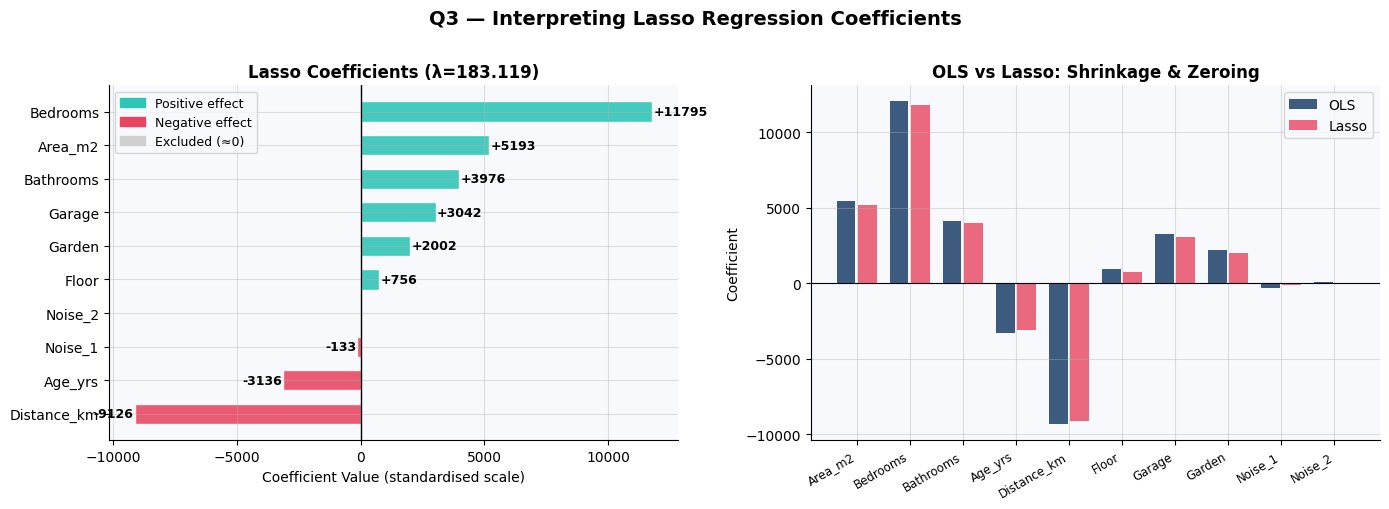

In [4]:
# ── Q3: Coefficient interpretation with a realistic dataset ─────────────────
np.random.seed(7)
n3 = 250

# House-price inspired dataset
feature_names = ['Area_m2','Bedrooms','Bathrooms','Age_yrs',
                  'Distance_km','Floor','Garage','Garden',
                  'Noise_1','Noise_2']
true_coefs = np.array([120.0, 8000, 5000, -300, -1500, 200, 6000, 3500, 0, 0])

X3 = np.column_stack([
    np.random.uniform(30,200,n3),   # Area
    np.random.randint(1,6,n3).astype(float),  # Bedrooms
    np.random.randint(1,4,n3).astype(float),  # Bathrooms
    np.random.uniform(0,40,n3),    # Age
    np.random.uniform(0.5,20,n3),  # Distance
    np.random.randint(1,15,n3).astype(float), # Floor
    np.random.randint(0,2,n3).astype(float),  # Garage
    np.random.randint(0,2,n3).astype(float),  # Garden
    np.random.randn(n3),           # Noise 1
    np.random.randn(n3),           # Noise 2
])
y3 = X3 @ true_coefs + np.random.randn(n3) * 8000

sc3 = StandardScaler()
X3s = sc3.fit_transform(X3)

# Fit Lasso (λ chosen via LassoCV)
lcv3 = LassoCV(cv=5, max_iter=20000, random_state=0).fit(X3s, y3)
coefs3 = lcv3.coef_

print('='*60)
print('  Lasso Coefficient Interpretation (standardised features)')
print('='*60)
print(f'  Optimal λ : {lcv3.alpha_:.4f}')
print()
print(f'  {"Feature":15} {"Lasso β":>12} {"Status":>15} {"Interpretation"}')
print('  ' + '-'*72)
for fname, coef, tc in zip(feature_names, coefs3, true_coefs):
    status = 'EXCLUDED' if abs(coef)<0.1 else ('+ve effect' if coef>0 else '-ve effect')
    interp = f'↑1 SD → ŷ {coef:+.0f}' if abs(coef)>=0.1 else 'Zeroed by Lasso'
    print(f'  {fname:15} {coef:>12.2f} {status:>15}   {interp}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sorted coefficient plot
sorted_i = np.argsort(coefs3)
bar_colors = [C1 if c<0 else (C4 if abs(c)>0.05 else '#D0D0D0') for c in coefs3[sorted_i]]
bars3 = axes[0].barh(np.array(feature_names)[sorted_i], coefs3[sorted_i],
                      color=bar_colors, alpha=0.88, edgecolor='white', height=0.6)
for bar, v in zip(bars3, coefs3[sorted_i]):
    if abs(v) > 0.05:
        axes[0].text(v + (50 if v>=0 else -50), bar.get_y()+bar.get_height()/2,
                     f'{v:+.0f}', va='center',
                     ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
axes[0].axvline(0, color='black', lw=1.0)
axes[0].set_title(f'Lasso Coefficients (λ={lcv3.alpha_:.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient Value (standardised scale)')
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color=C4, label='Positive effect'),
    Patch(color=C1, label='Negative effect'),
    Patch(color='#D0D0D0', label='Excluded (≈0)'),
], fontsize=9)

# Shrinkage: Lasso vs OLS
ols_coefs3 = LinearRegression().fit(X3s, y3).coef_
x_pos3 = np.arange(len(feature_names))
axes[1].bar(x_pos3-0.2, ols_coefs3, 0.35, color=C2, alpha=0.80, label='OLS')
axes[1].bar(x_pos3+0.2, coefs3,     0.35, color=C1, alpha=0.80, label='Lasso')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x_pos3)
axes[1].set_xticklabels(feature_names, rotation=30, ha='right', fontsize=8.5)
axes[1].set_title('OLS vs Lasso: Shrinkage & Zeroing', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Coefficient')
axes[1].legend(fontsize=10)

plt.suptitle('Q3 — Interpreting Lasso Regression Coefficients',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q4 — What are the tuning parameters of Lasso Regression, and how do they affect performance?


### 📖 Theory

#### Primary tuning parameter

| Parameter | Symbol | Effect |
|-----------|--------|--------|
| **Regularisation strength** | λ (alpha) | ↑λ → more shrinkage → sparser model → higher bias, lower variance |

#### Secondary / implementation parameters (`sklearn.Lasso`)

| Parameter | Default | Effect |
|-----------|---------|--------|
| `max_iter` | 1000 | Convergence; increase for large/complex datasets |
| `tol` | 1e-4 | Convergence tolerance; smaller = more precise |
| `fit_intercept` | True | Whether to centre y before fitting |
| `warm_start` | False | Reuse previous solution — speeds up path computation |
| `selection` | cyclic | Coefficient update order; `random` can be faster |

#### The bias-variance trade-off
```
λ → 0  :  OLS solution  (low bias, high variance)
λ → ∞  :  all β = 0    (high bias, zero variance — predicts mean)
λ*     :  optimal cross-validated balance
```


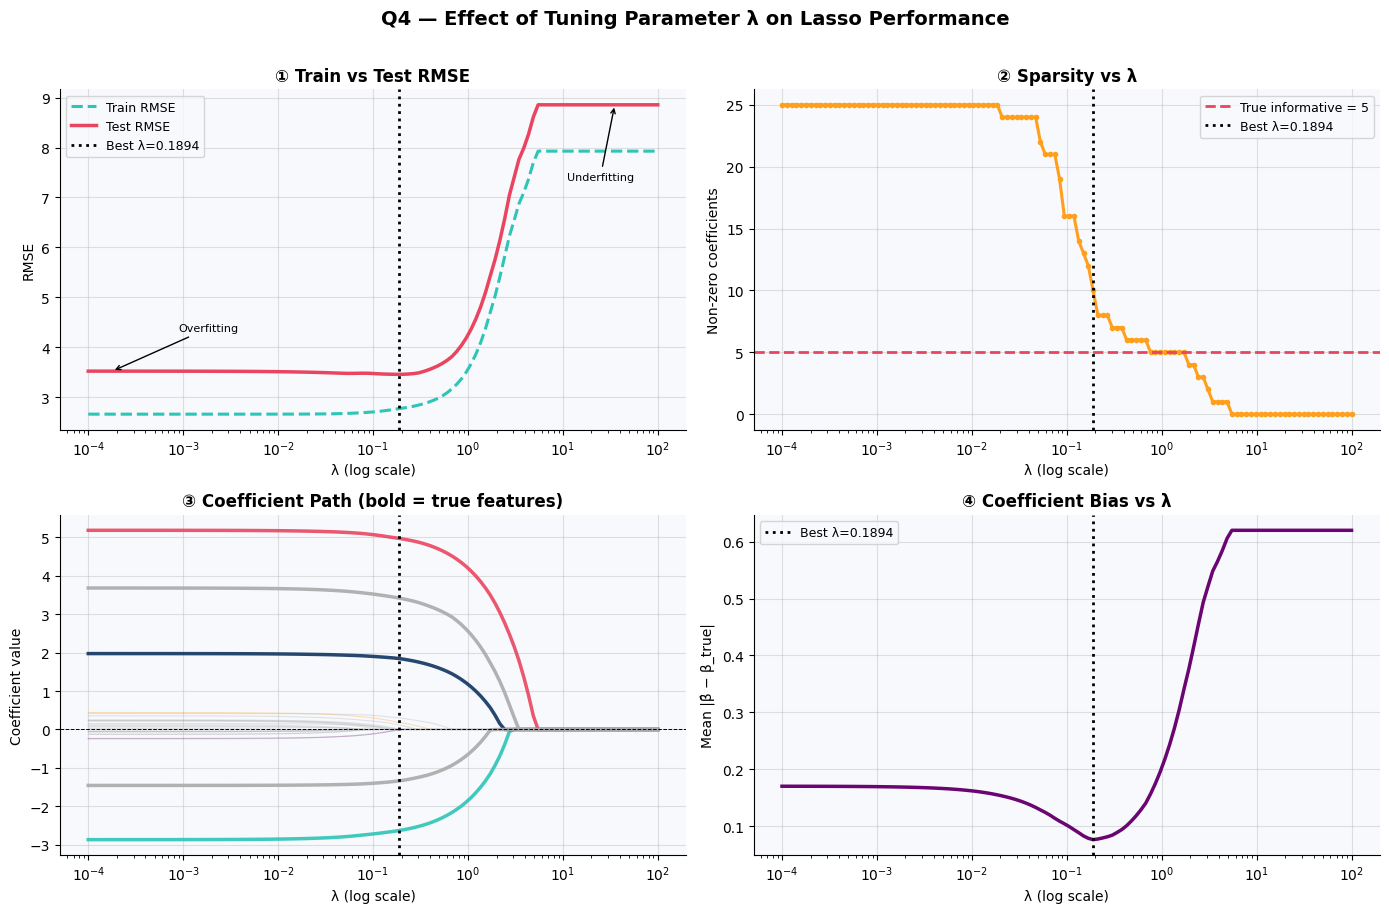

Optimal λ: 0.18937  |  Test RMSE: 3.4615
Features selected at optimal λ: 10 / 25


In [5]:
# ── Q4: Effect of λ on bias, variance, sparsity, and error ──────────────────
np.random.seed(42)
n4, p4 = 200, 25

true4 = np.zeros(p4)
true4[[0,1,3,7,12]] = [5, -3, 2, -1.5, 4]
X4 = np.random.randn(n4, p4)
y4 = X4 @ true4 + np.random.randn(n4)*3

X4_tr, X4_te, y4_tr, y4_te = train_test_split(X4, y4, test_size=0.25, random_state=1)
sc4 = StandardScaler()
X4_tr_s = sc4.fit_transform(X4_tr)
X4_te_s = sc4.transform(X4_te)

lambdas4  = np.logspace(-4, 2, 120)
tr_rmse4, te_rmse4, nz4, bias4 = [], [], [], []

for lam in lambdas4:
    m = Lasso(alpha=lam, max_iter=20000).fit(X4_tr_s, y4_tr)
    tr_rmse4.append(np.sqrt(mean_squared_error(y4_tr, m.predict(X4_tr_s))))
    te_rmse4.append(np.sqrt(mean_squared_error(y4_te, m.predict(X4_te_s))))
    nz4.append(np.sum(np.abs(m.coef_) > 1e-4))
    bias4.append(np.mean(np.abs(m.coef_ - true4)))

best_idx4 = np.argmin(te_rmse4)
best_lam4 = lambdas4[best_idx4]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Train vs Test RMSE
axes[0,0].semilogx(lambdas4, tr_rmse4, '--', color=C4, lw=2.2, label='Train RMSE')
axes[0,0].semilogx(lambdas4, te_rmse4, '-',  color=C1, lw=2.5, label='Test RMSE')
axes[0,0].axvline(best_lam4, color='black', ls=':', lw=2, label=f'Best λ={best_lam4:.4f}')
axes[0,0].set_xlabel('λ (log scale)'); axes[0,0].set_ylabel('RMSE')
axes[0,0].set_title('① Train vs Test RMSE', fontsize=12, fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].annotate('Overfitting', xy=(lambdas4[5], te_rmse4[5]),
                    xytext=(lambdas4[5]*5, te_rmse4[5]+0.8),
                    fontsize=8, arrowprops=dict(arrowstyle='->'))
axes[0,0].annotate('Underfitting', xy=(lambdas4[-10], te_rmse4[-10]),
                    xytext=(lambdas4[-20], te_rmse4[-10]-1.5),
                    fontsize=8, arrowprops=dict(arrowstyle='->'))

# Non-zero features vs λ
axes[0,1].semilogx(lambdas4, nz4, 'o-', color=C5, lw=2.2, ms=3)
axes[0,1].axhline(5, color=C1, ls='--', lw=2, label='True informative = 5')
axes[0,1].axvline(best_lam4, color='black', ls=':', lw=2, label=f'Best λ={best_lam4:.4f}')
axes[0,1].set_xlabel('λ (log scale)'); axes[0,1].set_ylabel('Non-zero coefficients')
axes[0,1].set_title('② Sparsity vs λ', fontsize=12, fontweight='bold')
axes[0,1].legend(fontsize=9)

# Coefficient paths
coef_paths4 = np.array([Lasso(alpha=a,max_iter=20000).fit(X4_tr_s,y4_tr).coef_ for a in lambdas4])
palette4 = [C1,C4,C5,C2,C6] + ['#AAAAAA']*(p4-5)
for i in range(p4):
    lw = 2.5 if i in [0,1,3,7,12] else 0.8
    al = 0.9 if i in [0,1,3,7,12] else 0.3
    axes[1,0].semilogx(lambdas4, coef_paths4[:,i], lw=lw, alpha=al,
                        color=palette4[i] if i<len(palette4) else '#AAAAAA')
axes[1,0].axvline(best_lam4, color='black', ls=':', lw=2)
axes[1,0].axhline(0, color='black', lw=0.7, ls='--')
axes[1,0].set_xlabel('λ (log scale)'); axes[1,0].set_ylabel('Coefficient value')
axes[1,0].set_title('③ Coefficient Path (bold = true features)', fontsize=12, fontweight='bold')

# Bias vs λ
axes[1,1].semilogx(lambdas4, bias4, color=C6, lw=2.5)
axes[1,1].axvline(best_lam4, color='black', ls=':', lw=2, label=f'Best λ={best_lam4:.4f}')
axes[1,1].set_xlabel('λ (log scale)'); axes[1,1].set_ylabel('Mean |β̂ − β_true|')
axes[1,1].set_title('④ Coefficient Bias vs λ', fontsize=12, fontweight='bold')
axes[1,1].legend(fontsize=9)

plt.suptitle('Q4 — Effect of Tuning Parameter λ on Lasso Performance',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Optimal λ: {best_lam4:.5f}  |  Test RMSE: {te_rmse4[best_idx4]:.4f}')
print(f'Features selected at optimal λ: {nz4[best_idx4]} / {p4}')


---
## Q5 — Can Lasso Regression be used for non-linear regression problems? If yes, how?


### 📖 Theory

**Yes** — Lasso is a *linear model*, but it can capture non-linear relationships through
**feature engineering** before fitting.

#### Strategies

| Strategy | How | When to use |
|----------|-----|-------------|
| **Polynomial features** | Add X², X³, X₁·X₂ … | Smooth curved relationships |
| **Basis expansion** | Splines, RBF, Fourier | Periodic or complex shapes |
| **Log / sqrt transforms** | ln(X), √X | Skewed features |
| **Interaction terms** | X₁·X₂ | Feature interactions |
| **Kernel trick** | Project to high-d space | Combined with Lasso regulariser |

#### Lasso + Polynomial Features workflow
```
X (raw) ──► PolynomialFeatures ──► StandardScaler ──► Lasso
                (degree=d)           (essential!)      (λ via CV)
```

>  **Scaling is critical** after polynomial expansion — features span very different ranges.
> Lasso's sparsity then selects which polynomial terms actually matter.


  Lasso + Polynomial Features — Non-linear Regression Results
   Degree  Features  Non-zero    λ (opt)   Test RMSE       R²
  --------------------------------------------------------
        1         1         1     0.0061      6.2956   0.5074
        3         3         3     0.0063      1.7607   0.9615
        6         6         4     0.0063      1.2989   0.9790
       10        10         6     0.0063      1.3141   0.9785


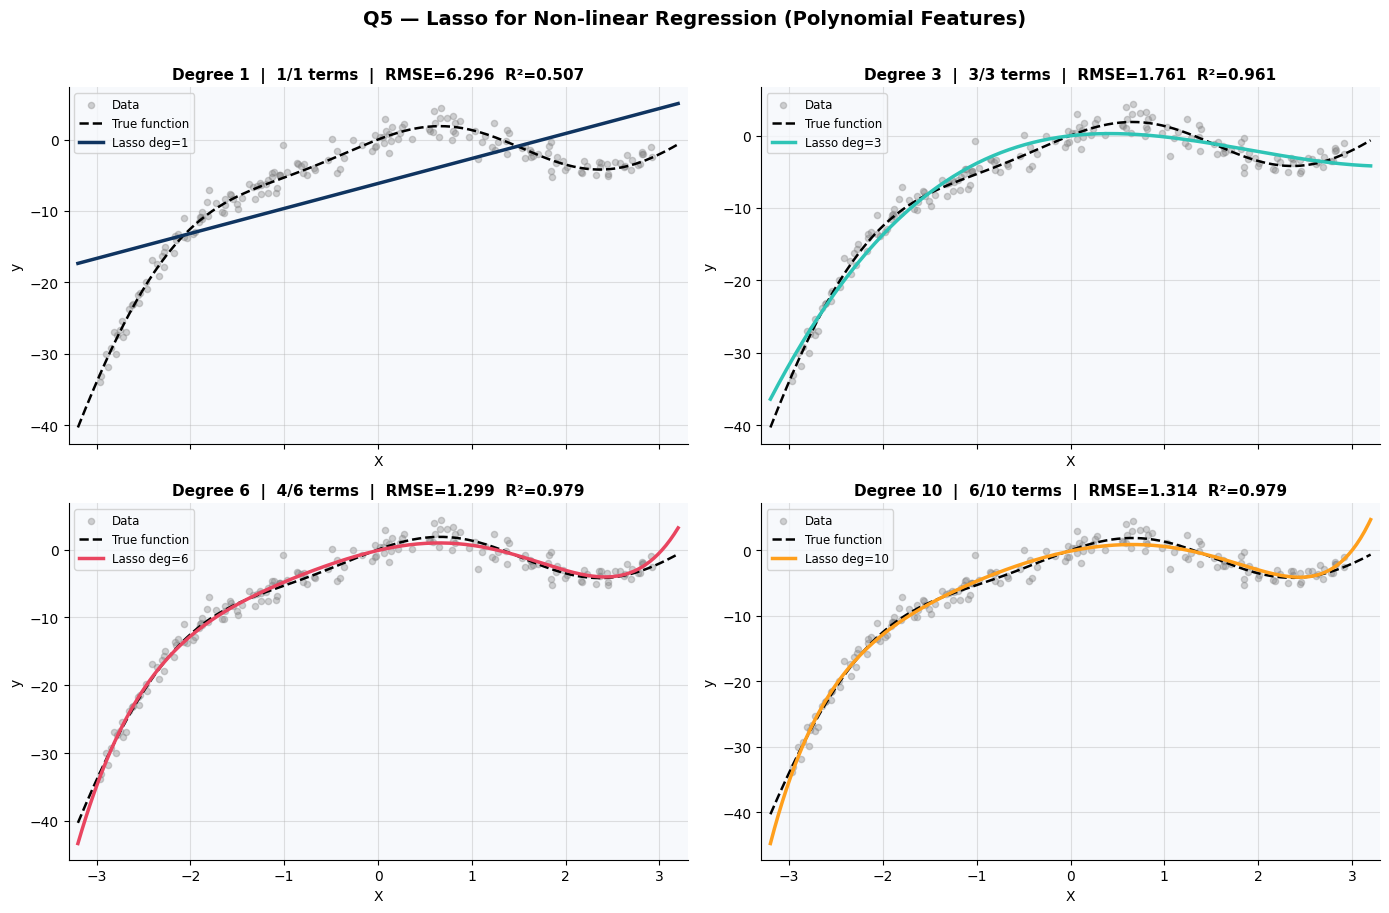

In [6]:
# ── Q5: Lasso for non-linear regression via polynomial features ──────────────
np.random.seed(42)
n5 = 180

# Non-linear ground truth: y = 0.5x³ - 2x² + x + sin(2x) + noise
X5_raw = np.sort(np.random.uniform(-3, 3, n5))
y5 = 0.5*X5_raw**3 - 2*X5_raw**2 + X5_raw + 2*np.sin(2*X5_raw) + np.random.randn(n5)*1.2

X5 = X5_raw.reshape(-1, 1)
X5_tr, X5_te, y5_tr, y5_te = train_test_split(X5, y5, test_size=0.25, random_state=3)

degrees  = [1, 3, 6, 10]
results5 = {}

for deg in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso',  LassoCV(cv=5, max_iter=20000, random_state=0))
    ])
    pipe.fit(X5_tr, y5_tr)
    X5_plot = np.linspace(-3.2, 3.2, 300).reshape(-1,1)
    results5[deg] = {
        'pipe'      : pipe,
        'y_plot'    : pipe.predict(X5_plot),
        'test_rmse' : np.sqrt(mean_squared_error(y5_te, pipe.predict(X5_te))),
        'r2'        : r2_score(y5_te, pipe.predict(X5_te)),
        'lam'       : pipe.named_steps['lasso'].alpha_,
        'nz'        : np.sum(np.abs(pipe.named_steps['lasso'].coef_) > 1e-4),
        'n_feat'    : pipe.named_steps['poly'].n_output_features_,
    }

print('='*68)
print('  Lasso + Polynomial Features — Non-linear Regression Results')
print('='*68)
print(f'  {"Degree":>7} {"Features":>9} {"Non-zero":>9} {"λ (opt)":>10} {"Test RMSE":>11} {"R²":>8}')
print('  ' + '-'*56)
for deg, r in results5.items():
    print(f'  {deg:>7} {r["n_feat"]:>9} {r["nz"]:>9} {r["lam"]:>10.4f} {r["test_rmse"]:>11.4f} {r["r2"]:>8.4f}')

X5_plot = np.linspace(-3.2, 3.2, 300).reshape(-1,1)
X5_true = np.linspace(-3.2, 3.2, 300)
y5_true = 0.5*X5_true**3 - 2*X5_true**2 + X5_true + 2*np.sin(2*X5_true)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()
line_cols = [C2, C4, C1, C5]

for ax, (deg, r), col in zip(axes, results5.items(), line_cols):
    ax.scatter(X5_raw, y5, alpha=0.35, color='grey', s=20, label='Data')
    ax.plot(X5_true, y5_true, color='black', lw=1.8, ls='--', label='True function')
    ax.plot(X5_true, r['y_plot'], color=col, lw=2.5, label=f'Lasso deg={deg}')
    ax.set_title(f'Degree {deg}  |  {r["nz"]}/{r["n_feat"]} terms  |  '
                 f'RMSE={r["test_rmse"]:.3f}  R²={r["r2"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('y'); ax.set_xlabel('X')
    ax.legend(fontsize=8.5)
    ax.set_xlim(-3.3, 3.3)

plt.suptitle('Q5 — Lasso for Non-linear Regression (Polynomial Features)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q6 — What is the difference between Ridge Regression and Lasso Regression?


### 📖 Theory

| Property | Ridge (L2) | Lasso (L1) |
|----------|-----------|------------|
| **Penalty** | $\lambda\sum\beta_j^2$ | $\lambda\sum|\beta_j|$ |
| **Geometry** | Circular/spherical | Diamond/hypercube |
| **Coefficients → 0?** | ❌ Only asymptotically | ✅ Exactly zero |
| **Feature selection** | ❌ No | ✅ Automatic |
| **Multicollinearity** | Distributes weight | Picks one, drops rest |
| **Sparsity** | Dense model | Sparse model |
| **Solution** | Closed form $(X^TX+\lambda I)^{-1}X^Ty$ | Coordinate descent (iterative) |
| **Differentiability** | Everywhere | Not at β=0 |
| **Best when** | All features relevant | Many irrelevant features |

#### Elastic Net — best of both
$$\text{Elastic Net} = \text{RSS} + \lambda_1\sum|\beta_j| + \lambda_2\sum\beta_j^2$$
Combines L1 sparsity with L2 stability for correlated predictors.


  Ridge        | RMSE=3.088 | R²=0.840 | Non-zero coefs=18/18
  Lasso        | RMSE=2.963 | R²=0.853 | Non-zero coefs=16/18
  ElasticNet   | RMSE=3.266 | R²=0.821 | Non-zero coefs=10/18


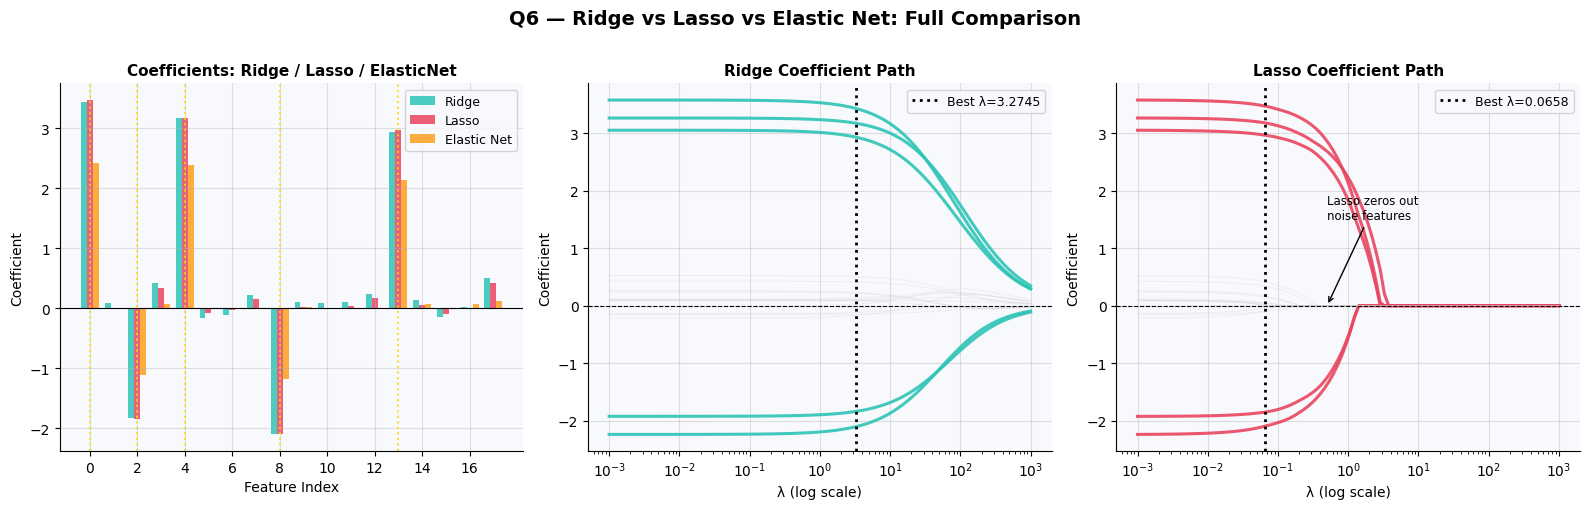

In [7]:
# ── Q6: Comprehensive Ridge vs Lasso comparison ──────────────────────────────
np.random.seed(42)
n6, p6 = 150, 18
true6 = np.zeros(p6)
true6[[0,2,4,8,13]] = [4,-2,3,-1.5,2.5]
X6 = np.random.randn(n6, p6)
y6 = X6 @ true6 + np.random.randn(n6)*2.5

X6_tr, X6_te, y6_tr, y6_te = train_test_split(X6, y6, test_size=0.25, random_state=0)
sc6 = StandardScaler()
X6_tr_s = sc6.fit_transform(X6_tr)
X6_te_s = sc6.transform(X6_te)

from sklearn.linear_model import RidgeCV
alphas6 = np.logspace(-3, 3, 100)
ridge6 = RidgeCV(alphas=alphas6, cv=5).fit(X6_tr_s, y6_tr)
lasso6 = LassoCV(alphas=alphas6, cv=5, max_iter=20000).fit(X6_tr_s, y6_tr)
enet6  = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=20000).fit(X6_tr_s, y6_tr)

for name, mdl in [('Ridge', ridge6), ('Lasso', lasso6), ('ElasticNet', enet6)]:
    rmse = np.sqrt(mean_squared_error(y6_te, mdl.predict(X6_te_s)))
    r2   = r2_score(y6_te, mdl.predict(X6_te_s))
    nz   = np.sum(np.abs(mdl.coef_) > 1e-4)
    print(f'  {name:12} | RMSE={rmse:.3f} | R²={r2:.3f} | Non-zero coefs={nz}/{p6}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Coefficient comparison bar chart
x6  = np.arange(p6)
w6  = 0.25
axes[0].bar(x6-w6, ridge6.coef_, w6, color=C4, alpha=0.85, label='Ridge')
axes[0].bar(x6,    lasso6.coef_, w6, color=C1, alpha=0.85, label='Lasso')
axes[0].bar(x6+w6, enet6.coef_,  w6, color=C5, alpha=0.85, label='Elastic Net')
axes[0].axhline(0, color='black', lw=0.8)
# Mark true features
for ti in [0,2,4,8,13]:
    axes[0].axvline(ti, color='gold', lw=1.5, ls=':', alpha=0.8)
axes[0].set_title('Coefficients: Ridge / Lasso / ElasticNet', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Feature Index'); axes[0].set_ylabel('Coefficient')
axes[0].legend(fontsize=9)
axes[0].set_xticks(x6[::2])

# Coefficient path comparison
ridge_paths6 = np.array([Ridge(alpha=a).fit(X6_tr_s,y6_tr).coef_ for a in alphas6])
lasso_paths6 = np.array([Lasso(alpha=a,max_iter=20000).fit(X6_tr_s,y6_tr).coef_ for a in alphas6])

for i in range(p6):
    lw = 2.2 if i in [0,2,4,8,13] else 0.7
    al = 0.9 if i in [0,2,4,8,13] else 0.25
    axes[1].semilogx(alphas6, ridge_paths6[:,i], lw=lw, alpha=al, color=C4 if i in [0,2,4,8,13] else '#CCCCCC')
    axes[2].semilogx(alphas6, lasso_paths6[:,i], lw=lw, alpha=al, color=C1 if i in [0,2,4,8,13] else '#CCCCCC')

for ax, name, opt_lam, col in [
    (axes[1], 'Ridge', ridge6.alpha_, C4),
    (axes[2], 'Lasso', lasso6.alpha_, C1)
]:
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvline(opt_lam, color='black', ls=':', lw=2, label=f'Best λ={opt_lam:.4f}')
    ax.set_xlabel('λ (log scale)'); ax.set_ylabel('Coefficient')
    ax.set_title(f'{name} Coefficient Path', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

axes[2].annotate('Lasso zeros out\nnoise features', xy=(0.5, 0),
                  xytext=(0.5, 1.5), fontsize=8.5,
                  arrowprops=dict(arrowstyle='->', color='black'))

plt.suptitle('Q6 — Ridge vs Lasso vs Elastic Net: Full Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Q7 — Can Lasso Regression handle multicollinearity? If yes, how?


### 📖 Theory

**Yes, partially** — Lasso handles multicollinearity differently from Ridge.

#### Lasso behaviour under multicollinearity

When features are highly correlated, Lasso tends to:
1. **Select one** feature from a correlated group (arbitrarily)
2. **Zero out** the remaining correlated features
3. Produce an **unstable selection** — different samples may select different features

#### Ridge vs Lasso vs Elastic Net under multicollinearity

| Model | Behaviour | Stability |
|-------|-----------|----------|
| **Ridge** | Distributes weight equally among correlated features | ✅ Stable |
| **Lasso** | Picks one, zeros others — arbitrary choice | ⚠️ Unstable |
| **Elastic Net** | Groups correlated features together | ✅ Stable + sparse |

> 💡 **Recommendation:** If multicollinearity is the main concern, prefer **Elastic Net**
> (combines Ridge's stability with Lasso's sparsity).


  Coefficient Variance vs Correlation (100 repetitions each)
       ρ    Lasso Var    Ridge Var     ENet Var
  --------------------------------------------
    0.00      0.02800      0.03011      0.02634
    0.50      0.02950      0.03448      0.02879
    0.85      0.04019      0.06737      0.04466
    0.95      0.07261      0.12828      0.04700
    0.99      0.13247      0.20275      0.03477


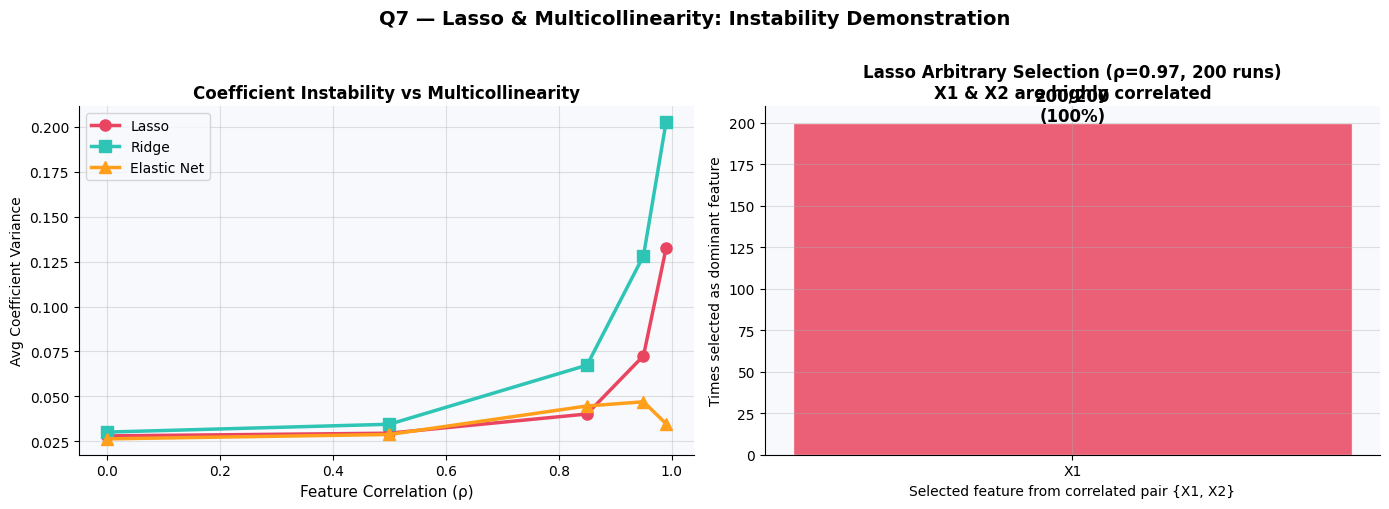


⚠  Lasso selection between correlated features is nearly random!
✅  Use Elastic Net when both sparsity and stability are needed.


In [8]:
# ── Q7: Lasso vs Ridge under multicollinearity ──────────────────────────────
np.random.seed(42)
n7, n_reps = 120, 100

correlations7 = [0.0, 0.5, 0.85, 0.95, 0.99]
lasso_var7, ridge_var7, enet_var7 = [], [], []

for rho in correlations7:
    cov = [[1,rho,rho/2,0],[rho,1,rho/3,0],[rho/2,rho/3,1,0],[0,0,0,1]]
    l_coefs, r_coefs, e_coefs = [], [], []
    for _ in range(n_reps):
        X7 = np.random.multivariate_normal([0]*4, cov, n7)
        y7 = 3*X7[:,0] + X7[:,2] - 1.5*X7[:,3] + np.random.randn(n7)*1.5
        X7s = StandardScaler().fit_transform(X7)
        l_coefs.append(Lasso(alpha=0.1,max_iter=10000).fit(X7s,y7).coef_)
        r_coefs.append(Ridge(alpha=1.0).fit(X7s,y7).coef_)
        e_coefs.append(ElasticNet(alpha=0.1,l1_ratio=0.5,max_iter=10000).fit(X7s,y7).coef_)
    lasso_var7.append(np.var(np.array(l_coefs), axis=0).mean())
    ridge_var7.append(np.var(np.array(r_coefs), axis=0).mean())
    enet_var7.append(np.var(np.array(e_coefs), axis=0).mean())

print('='*62)
print('  Coefficient Variance vs Correlation (100 repetitions each)')
print('='*62)
print(f'  {"ρ":>6} {"Lasso Var":>12} {"Ridge Var":>12} {"ENet Var":>12}')
print('  ' + '-'*44)
for rho, lv, rv, ev in zip(correlations7, lasso_var7, ridge_var7, enet_var7):
    print(f'  {rho:>6.2f} {lv:>12.5f} {rv:>12.5f} {ev:>12.5f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variance vs correlation
axes[0].plot(correlations7, lasso_var7, 'o-', color=C1, lw=2.5, ms=8, label='Lasso')
axes[0].plot(correlations7, ridge_var7, 's-', color=C4, lw=2.5, ms=8, label='Ridge')
axes[0].plot(correlations7, enet_var7,  '^-', color=C5, lw=2.5, ms=8, label='Elastic Net')
axes[0].set_xlabel('Feature Correlation (ρ)', fontsize=11)
axes[0].set_ylabel('Avg Coefficient Variance')
axes[0].set_title('Coefficient Instability vs Multicollinearity', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Show arbitrary feature selection by Lasso at high correlation
rho_high = 0.97
cov_h = [[1,rho_high,0,0],[rho_high,1,0,0],[0,0,1,0],[0,0,0,1]]
lasso_sel = []
for _ in range(200):
    Xh = np.random.multivariate_normal([0]*4, cov_h, n7)
    yh = 3*Xh[:,0] + Xh[:,2] + np.random.randn(n7)*1.5
    Xhs = StandardScaler().fit_transform(Xh)
    coef_h = Lasso(alpha=0.2,max_iter=10000).fit(Xhs,yh).coef_
    # Which of X0,X1 (correlated pair) was selected?
    lasso_sel.append('X1' if abs(coef_h[0])>abs(coef_h[1]) else 'X2')

counts = pd.Series(lasso_sel).value_counts()
axes[1].bar(counts.index, counts.values, color=[C1, C4], alpha=0.85,
             width=0.4, edgecolor='white')
for i, (feat, cnt) in enumerate(counts.items()):
    axes[1].text(i, cnt+1, f'{cnt}/200\n({cnt/2:.0f}%)',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Lasso Arbitrary Selection (ρ=0.97, 200 runs)\nX1 & X2 are highly correlated',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Times selected as dominant feature')
axes[1].set_xlabel('Selected feature from correlated pair {X1, X2}')

plt.suptitle('Q7 — Lasso & Multicollinearity: Instability Demonstration',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\n⚠  Lasso selection between correlated features is nearly random!')
print('✅  Use Elastic Net when both sparsity and stability are needed.')


---
## Q8 — How do you choose the optimal value of λ in Lasso Regression?


### 📖 Theory

#### Methods for selecting optimal λ

| Method | Description | Pros | Cons |
|--------|-------------|------|------|
| **k-Fold Cross-Validation** | Grid search, pick λ minimising CV error | Gold standard | Computationally heavy |
| **LassoCV** | Efficient built-in sklearn CV along regularisation path | Fast + accurate | — |
| **1-SE Rule** | Pick largest λ within 1 std error of minimum | More parsimonious | May underfit |
| **Information Criteria** | AIC / BIC penalise model complexity | No data split needed | Gaussian assumption |
| **Validation curve** | Plot train vs val error vs λ | Visual intuition | Needs holdout set |

#### Practical grid recommendation
```python
alphas = np.logspace(-4, 2, 200)   # logarithmic grid from 1e-4 to 100
model  = LassoCV(alphas=alphas, cv=5, max_iter=20000)
```

> ✅ **Always standardise features before running `LassoCV`** — otherwise the penalty
> scales unevenly across features with different magnitudes.


  Lambda Selection — All Methods Comparison
  Manual k-Fold CV      λ=0.12609  RMSE=3.293  Non-zero=13/20
  1-SE Rule             λ=0.66912  RMSE=3.244  Non-zero=5/20
  LassoCV               λ=0.18270  RMSE=3.253  Non-zero=10/20
  AIC                   λ=0.18270  RMSE=3.253  Non-zero=10/20
  BIC                   λ=0.34964  RMSE=3.195  Non-zero=5/20


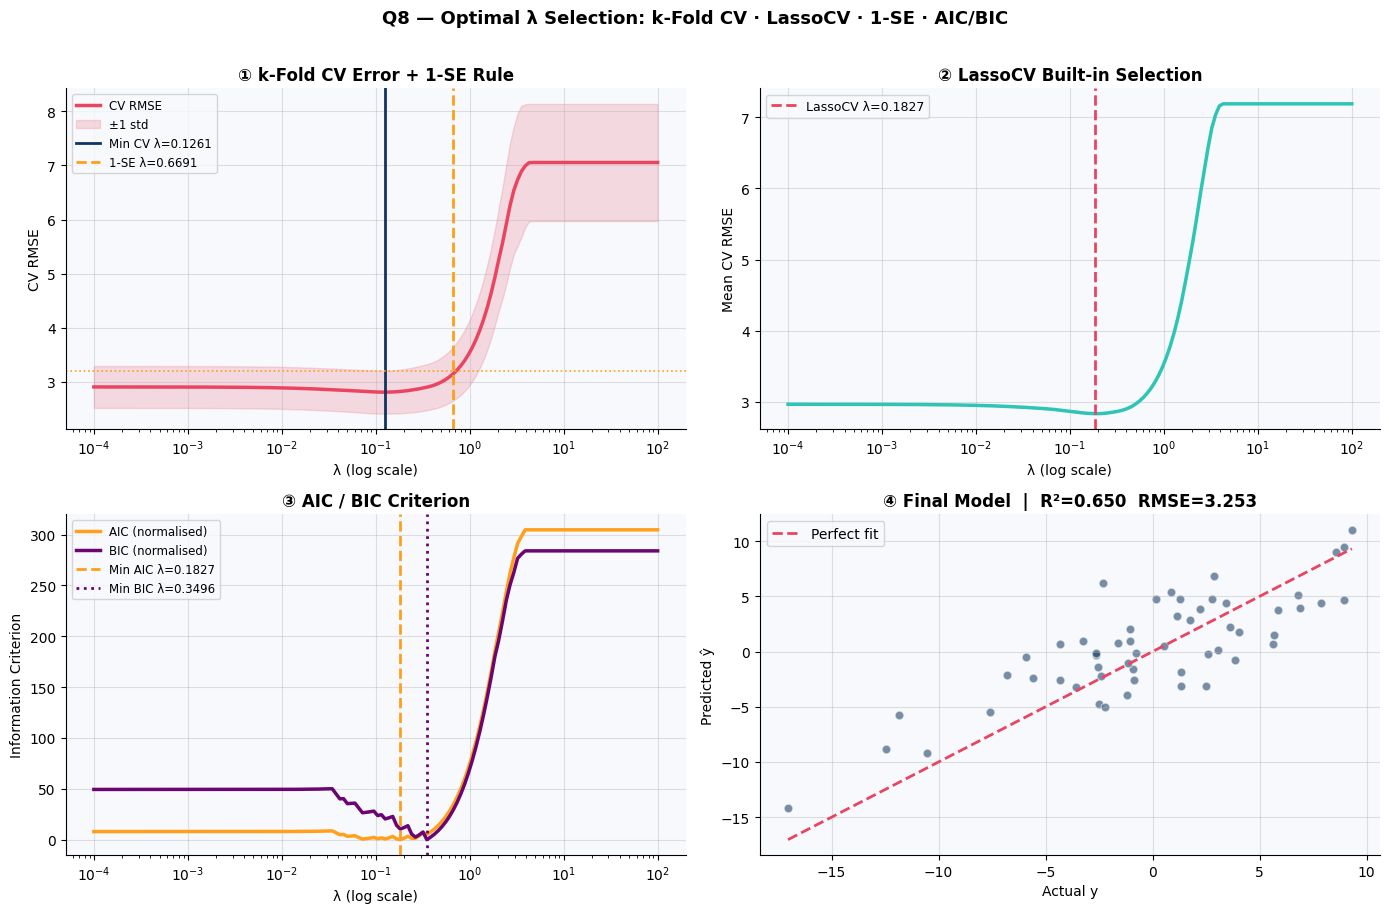

In [9]:
# ── Q8: All lambda selection methods compared ─────────────────────────────────
np.random.seed(42)
n8, p8 = 220, 20
true8 = np.zeros(p8); true8[[0,1,3,6,11]] = [4,-2.5,3,1.8,-2]
X8 = np.random.randn(n8, p8)
y8 = X8 @ true8 + np.random.randn(n8)*3

X8_tr, X8_te, y8_tr, y8_te = train_test_split(X8, y8, test_size=0.25, random_state=7)
sc8 = StandardScaler()
X8_tr_s = sc8.fit_transform(X8_tr)
X8_te_s = sc8.transform(X8_te)

alphas8 = np.logspace(-4, 2, 150)

# ── Method 1: Manual k-Fold CV ────────────────────────────────────────────────
kf8 = KFold(n_splits=5, shuffle=True, random_state=0)
cv_mean8, cv_std8 = [], []
for a in alphas8:
    sc = cross_val_score(Lasso(alpha=a, max_iter=20000), X8_tr_s, y8_tr,
                          cv=kf8, scoring='neg_root_mean_squared_error')
    cv_mean8.append(-sc.mean()); cv_std8.append(sc.std())
cv_mean8 = np.array(cv_mean8); cv_std8 = np.array(cv_std8)
best_idx_cv = np.argmin(cv_mean8)
best_lam_cv = alphas8[best_idx_cv]

# 1-SE rule
threshold_1se = cv_mean8[best_idx_cv] + cv_std8[best_idx_cv]
idx_1se = np.where(cv_mean8 <= threshold_1se)[0]
best_lam_1se = alphas8[idx_1se[-1]]   # largest λ still within 1 SE

# ── Method 2: LassoCV ─────────────────────────────────────────────────────────
lcv8 = LassoCV(alphas=alphas8, cv=5, max_iter=20000, random_state=0).fit(X8_tr_s, y8_tr)
best_lam_lcv = lcv8.alpha_

# ── Method 3: AIC / BIC ───────────────────────────────────────────────────────
def aic_bic(X, y, alpha):
    n, p = X.shape
    m = Lasso(alpha=alpha, max_iter=20000).fit(X, y)
    rss = np.sum((y - m.predict(X))**2)
    k   = np.sum(np.abs(m.coef_) > 1e-6) + 1
    aic = n*np.log(rss/n) + 2*k
    bic = n*np.log(rss/n) + k*np.log(n)
    return aic, bic

aic_vals, bic_vals = zip(*[aic_bic(X8_tr_s, y8_tr, a) for a in alphas8])
best_lam_aic = alphas8[np.argmin(aic_vals)]
best_lam_bic = alphas8[np.argmin(bic_vals)]

print('='*56)
print('  Lambda Selection — All Methods Comparison')
print('='*56)
for method, lam in [('Manual k-Fold CV', best_lam_cv),
                     ('1-SE Rule',        best_lam_1se),
                     ('LassoCV',          best_lam_lcv),
                     ('AIC',              best_lam_aic),
                     ('BIC',              best_lam_bic)]:
    m = Lasso(alpha=lam, max_iter=20000).fit(X8_tr_s, y8_tr)
    rmse = np.sqrt(mean_squared_error(y8_te, m.predict(X8_te_s)))
    nz   = np.sum(np.abs(m.coef_) > 1e-4)
    print(f'  {method:20}  λ={lam:.5f}  RMSE={rmse:.3f}  Non-zero={nz}/{p8}')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# CV error curve
axes[0,0].semilogx(alphas8, cv_mean8, color=C1, lw=2.5, label='CV RMSE')
axes[0,0].fill_between(alphas8, cv_mean8-cv_std8, cv_mean8+cv_std8,
                         alpha=0.18, color=C1, label='±1 std')
axes[0,0].axvline(best_lam_cv,  color=C2, lw=2,   ls='-',  label=f'Min CV λ={best_lam_cv:.4f}')
axes[0,0].axvline(best_lam_1se, color=C5, lw=2,   ls='--', label=f'1-SE λ={best_lam_1se:.4f}')
axes[0,0].axhline(threshold_1se, color=C5, lw=1.2, ls=':')
axes[0,0].set_xlabel('λ (log scale)'); axes[0,0].set_ylabel('CV RMSE')
axes[0,0].set_title('① k-Fold CV Error + 1-SE Rule', fontsize=12, fontweight='bold')
axes[0,0].legend(fontsize=8.5)

# LassoCV heatmap
axes[0,1].semilogx(lcv8.alphas_, lcv8.mse_path_.mean(axis=1)**0.5, color=C4, lw=2.5)
axes[0,1].axvline(best_lam_lcv, color=C1, lw=2, ls='--', label=f'LassoCV λ={best_lam_lcv:.4f}')
axes[0,1].set_xlabel('λ (log scale)'); axes[0,1].set_ylabel('Mean CV RMSE')
axes[0,1].set_title('② LassoCV Built-in Selection', fontsize=12, fontweight='bold')
axes[0,1].legend(fontsize=9)

# AIC / BIC
aic_norm = (np.array(aic_vals)-np.min(aic_vals))
bic_norm = (np.array(bic_vals)-np.min(bic_vals))
axes[1,0].semilogx(alphas8, aic_norm, color=C5, lw=2.5, label='AIC (normalised)')
axes[1,0].semilogx(alphas8, bic_norm, color=C6, lw=2.5, label='BIC (normalised)')
axes[1,0].axvline(best_lam_aic, color=C5, lw=2, ls='--', label=f'Min AIC λ={best_lam_aic:.4f}')
axes[1,0].axvline(best_lam_bic, color=C6, lw=2, ls=':',  label=f'Min BIC λ={best_lam_bic:.4f}')
axes[1,0].set_xlabel('λ (log scale)'); axes[1,0].set_ylabel('Information Criterion')
axes[1,0].set_title('③ AIC / BIC Criterion', fontsize=12, fontweight='bold')
axes[1,0].legend(fontsize=8.5)

# Final model: actual vs predicted
best_final = Lasso(alpha=best_lam_lcv, max_iter=20000).fit(X8_tr_s, y8_tr)
y8_pred = best_final.predict(X8_te_s)
axes[1,1].scatter(y8_te, y8_pred, alpha=0.55, color=C2, s=40, edgecolors='white')
mn8, mx8 = y8_te.min(), y8_te.max()
axes[1,1].plot([mn8,mx8],[mn8,mx8],'--', color=C1, lw=2, label='Perfect fit')
r2_fin = r2_score(y8_te, y8_pred)
rmse_fin = np.sqrt(mean_squared_error(y8_te, y8_pred))
axes[1,1].set_xlabel('Actual y'); axes[1,1].set_ylabel('Predicted ŷ')
axes[1,1].set_title(f'④ Final Model  |  R²={r2_fin:.3f}  RMSE={rmse_fin:.3f}',
                     fontsize=12, fontweight='bold')
axes[1,1].legend(fontsize=10)

plt.suptitle('Q8 — Optimal λ Selection: k-Fold CV · LassoCV · 1-SE · AIC/BIC',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
